In [2]:
# %pip install tensorflow_hub

In [6]:
# pip install opencv-python

In [7]:
import numpy as np 
import PIL.Image as Image
import cv2
import os 
import matplotlib.pyplot as plt 
import tensorflow as tf 
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

C:\Users\sawsu\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Make predictions using ready made model (without any training)

In [8]:
IMAGE_SHAPE=(224,224)
base_model=tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SHAPE+(3,), 
    include_top=True, 
    weights='imagenet'
)
model=tf.keras.Sequential([base_model])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1000)                │       3,538,984 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

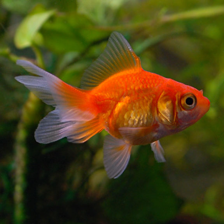

In [9]:
gold_fish=Image.open('goldfish.jpg.jpeg').resize(IMAGE_SHAPE)
gold_fish

In [10]:
gold_fish=np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [11]:
gold_fish[np.newaxis,...]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [12]:
result=model.predict(gold_fish[np.newaxis,...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(1, 1000)

In [13]:
predicted_label_index=np.argmax(result)
predicted_label_index

np.int64(1)

In [14]:
# tf.keras.utils.get_file('ImageNetLabels.txt','https://stronge.googleleapis.com')
image_labels=[] 
with open ('ImageNetLabels.txt','r') as f:
    image_labels=f.read().splitlines() 
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [15]:
image_labels[predicted_label_index+1]

'goldfish'

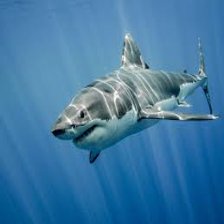

In [16]:
shark_fish=Image.open('shark.jpg').resize(IMAGE_SHAPE)
shark_fish

In [17]:
shark_fish=np.array(shark_fish)/255.0
shark_fish.shape

(224, 224, 3)

In [18]:
shark_fish[np.newaxis,...]

array([[[[0.20784314, 0.42745098, 0.61960784],
         [0.20784314, 0.42745098, 0.61960784],
         [0.20784314, 0.42745098, 0.61960784],
         ...,
         [0.20784314, 0.43921569, 0.65098039],
         [0.20784314, 0.43921569, 0.65882353],
         [0.20784314, 0.43921569, 0.65882353]],

        [[0.22745098, 0.44705882, 0.63921569],
         [0.22745098, 0.44705882, 0.63921569],
         [0.22745098, 0.44705882, 0.63921569],
         ...,
         [0.20784314, 0.43921569, 0.65098039],
         [0.20784314, 0.43921569, 0.65882353],
         [0.20784314, 0.43921569, 0.65882353]],

        [[0.23529412, 0.45490196, 0.64705882],
         [0.23529412, 0.45490196, 0.64705882],
         [0.23529412, 0.45490196, 0.64705882],
         ...,
         [0.20784314, 0.43921569, 0.65098039],
         [0.20784314, 0.43921569, 0.65882353],
         [0.20784314, 0.43921569, 0.65882353]],

        ...,

        [[0.        , 0.29803922, 0.51764706],
         [0.        , 0.29803922, 0.51764706]

In [19]:
result=model.predict(shark_fish[np.newaxis,...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


(1, 1000)

In [20]:
# pip install tensorflow_hub

In [21]:
import numpy as np
import cv2
import PIL.Image as Image
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import warnings 
warnings.filterwarnings('ignore')

In [22]:
IMAGE_SHAPE=(224,224)
base_model=tf.keras.applications.MobileNetV2(
 input_shape=IMAGE_SHAPE+(3,),
 include_top=True,
 weights='imagenet'    
)

In [23]:
model=tf.keras.Sequential([base_model])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1000)                │       3,538,984 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

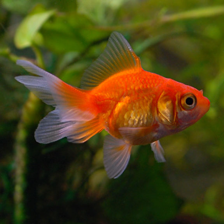

In [24]:
gold_fish=Image.open("goldfish.jpg.jpeg").resize(IMAGE_SHAPE)
gold_fish

In [25]:
gold_fish=np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [26]:
gold_fish[np.newaxis]

array([[[[0.28235294, 0.33333333, 0.07058824],
         [0.31372549, 0.37254902, 0.09019608],
         [0.34901961, 0.41960784, 0.11764706],
         ...,
         [0.32941176, 0.39215686, 0.00392157],
         [0.32156863, 0.38431373, 0.00392157],
         [0.30980392, 0.36862745, 0.        ]],

        [[0.28627451, 0.33333333, 0.08235294],
         [0.3254902 , 0.38039216, 0.10980392],
         [0.35294118, 0.42352941, 0.12941176],
         ...,
         [0.32156863, 0.38039216, 0.00392157],
         [0.31372549, 0.37254902, 0.00392157],
         [0.30196078, 0.36078431, 0.        ]],

        [[0.28627451, 0.33333333, 0.08627451],
         [0.31372549, 0.36862745, 0.10196078],
         [0.34509804, 0.41568627, 0.12941176],
         ...,
         [0.31764706, 0.37647059, 0.00392157],
         [0.30980392, 0.36862745, 0.00784314],
         [0.29803922, 0.35686275, 0.00392157]],

        ...,

        [[0.05490196, 0.10980392, 0.01568627],
         [0.05098039, 0.11372549, 0.01960784]

In [27]:
result=model.predict(gold_fish[np.newaxis,...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(1, 1000)

In [28]:
predicted_label_index=np.argmax(result)
predicted_label_index

np.int64(1)

In [29]:
image_labels=[]
with open("ImageNetLabels.txt","r") as f:
    image_labels=f.read().splitlines()
image_labels[:5]    

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [30]:
image_labels[predicted_label_index+1]

'goldfish'

In [31]:
#Load Flowers dataset

In [32]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [33]:
data_dir

'.\\datasets\\flower_photos'

In [34]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [35]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [36]:
image_count=len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [37]:
roses=list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

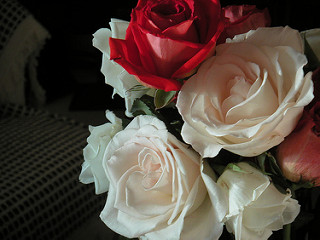

In [38]:
import PIL
PIL.Image.open(str(roses[1]))

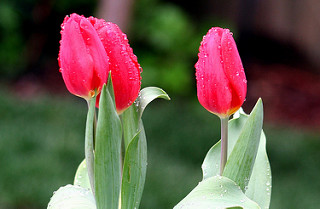

In [39]:
tulips=list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [40]:
# Read flowers images from disk into numpy array using opencv

In [41]:
flowers_image_dict={
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),
}

In [42]:
flowers_label_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4
}

In [43]:
flowers_image_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [44]:
str(flowers_image_dict['roses'][0])

'datasets\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [45]:
img=cv2.imread(str(flowers_image_dict['roses'][0]))

In [46]:
img.shape

(240, 179, 3)

In [47]:
cv2.resize(img,(224,224)).shape

(224, 224, 3)

In [ ]:
X, y = [], []

for flower_name, images in flowers_image_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        
       
        if img is not None:
            resized_img = cv2.resize(img, (224, 224))
            X.append(resized_img)
            y.append(flowers_label_dict[flower_name])
        else:
            
            print(f"Warning: Image not loaded -> {image}")


print(f"Total Images Loaded: {len(X)}")

In [43]:
predicted_label_index=np.argmax(result)
predicted_label_index

np.int64(1)

In [44]:
# tf.keras.utils.get_file('ImageNetLabels.txt','https://stronge.googleleapis.com')
image_labels=[] 
with open ('ImageNetLabels.txt','r') as f:
    image_labels=f.read().splitlines() 
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [17]:
image_labels[predicted_label_index+1]

'great white shark'

In [45]:
X,y=[],[] 
for flower_name, image in flower_images_dict.items(): 
    for image in images:
        img=cv2.imread(str(image))
        resized_img=cv2.resize(img,(224,224))
        X.append(resize_img)
        y.appendp(flower_labels_dict[flower_name])

NameError: name 'flower_images_dict' is not defined

In [ ]:
x=np.array(X)
y=np.array(y)

In [18]:
# Train test split 

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [22]:
# Preprocesing: Scale images 

In [ ]:
X_train_scaled=X_tran/255
X_test_scaled=X_test/255

In [23]:
# Makek Prediction using pre-trained model on new flowers datasets 

In [ ]:
X[0].shape

In [ ]:
IMAGE_SHAPE+(3,)

In [ ]:
x0_resized=cv2.resize(X[0],IMAGE_SHAPE)
x1_resized=cv2.resize(X[0],IMAGE_SHAPE)
x2_resized=cv2.resize(X[0],IMAGE_SHAPE)



In [ ]:
plt.axis('off' )
plt.imshow(X[0])

In [ ]:
plt.axis('off')
plt.imshow(X[1])

In [ ]:
predicted=model.predict(np.array([x0_resize,x2_resize]))
predicted=np.argmax(predicted,axis=1) 
predicted

In [ ]:
image_labels[795]

In [24]:
# Now take pre-trained model and retrain it using flowers images 

In [ ]:
import tensorflow as tf 
num_of_flowers=5
base_model=tf.keras.applications.MobileNetV2(input_shape=(224,224,3),
                                             include_top=False, 
                                             weights='imagenet', 
                                             pooling='avg' 
                                            ) 
base_model.trainable=False
model=tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(num_of_flowers,activation='softmax')])
model.summary()

In [ ]:
model.compile( 
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc']) 
model.fit(X_train_scaled,y_train,epochs=5)

In [ ]:
model.evaluate(X_test_scaled,y_test) 